Load preprocessed dataset for classifying

In [24]:
import pandas as pd
import numpy as np
file_path = "dataset/prepared/ClassifierPreparedDataset.csv"
df = pd.read_csv(file_path)

df

,NLOS,RANGE,FP_IDX,FP_AMP1,FP_AMP2,CIR_PWR,MAX_NOISE,RXPACC
0,0.0,3.90,745.0,18712.0,10250.0,11855.0,967.0,611.0
1,0.0,0.66,749.0,11239.0,6313.0,18968.0,1133.0,447.0
2,1.0,7.86,746.0,4355.0,5240.0,14699.0,894.0,723.0
3,1.0,3.48,750.0,8502.0,8416.0,8748.0,1127.0,1024.0
4,0.0,1.19,746.0,17845.0,18095.0,11380.0,1744.0,276.0
...,...,...,...,...,...,...,...,...
41995,0.0,2.43,745.0,12960.0,17703.0,9987.0,2379.0,276.0
41996,0.0,1.39,745.0,2235.0,15089.0,12559.0,1810.0,281.0
41997,1.0,5.48,747.0,7115.0,6262.0,1435.0,1092.0,1024.0
41998,1.0,3.40,745.0,6662.0,7683.0,1491.0,1077.0,1024.0


Check if features are linear

In [25]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import numpy as np

for col in df.columns:
    X = df[col].values.reshape(-1, 1)
    y = df["NLOS"]

    # Linear Model
    log_reg = LogisticRegression()
    log_reg.fit(X, y)
    y_pred_linear = log_reg.predict_proba(X)[:, 1]

    # Polynomial Model (Degree 2)
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X)
    log_reg_poly = LogisticRegression()
    log_reg_poly.fit(X_poly, y)
    y_pred_poly = log_reg_poly.predict_proba(X_poly)[:, 1]

    # Compare AUC Scores
    auc_linear = roc_auc_score(y, y_pred_linear)
    auc_poly = roc_auc_score(y, y_pred_poly)

    print(f"Column: {col}")
    print(f"Linear Model AUC: {auc_linear:.4f}")
    print(f"Polynomial Model AUC: {auc_poly:.4f}\n")

Column: NLOS
Linear Model AUC: 1.0000
Polynomial Model AUC: 1.0000

Column: RANGE
Linear Model AUC: 0.7572
Polynomial Model AUC: 0.7572

Column: FP_IDX
Linear Model AUC: 0.6987
Polynomial Model AUC: 0.6987

Column: FP_AMP1
Linear Model AUC: 0.7611
Polynomial Model AUC: 0.6914

Column: FP_AMP2
Linear Model AUC: 0.7968
Polynomial Model AUC: 0.7406

Column: CIR_PWR
Linear Model AUC: 0.7437
Polynomial Model AUC: 0.7437

Column: MAX_NOISE
Linear Model AUC: 0.6050
Polynomial Model AUC: 0.6050

Column: RXPACC
Linear Model AUC: 0.9047
Polynomial Model AUC: 0.9047



Extract NLOS column and put into y as class labels

In [26]:
X = df.drop(columns=["NLOS"])
y = df["NLOS"]

Split dataset into training and testing with 70:30 ratio


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

X_train shape: (29400, 7)
X_test shape: (12600, 7)


Train and Compare KNN, MLP neural network and Logistic Regression models

Train Logistic Regression model using different C hyperparameter values

Text(0, 0.5, 'Score')

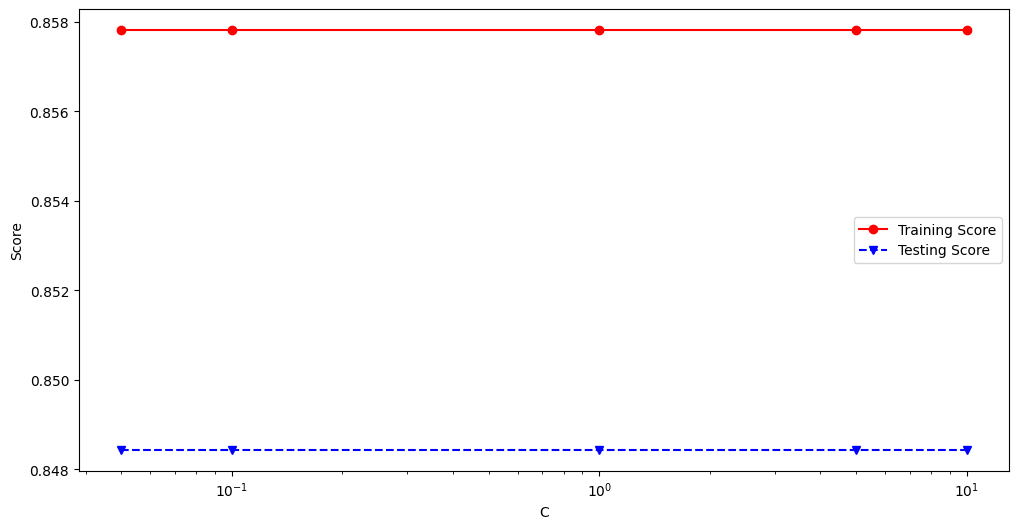

In [28]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

C = [0.05, 0.1, 1, 5, 10]

LRTrainAcc = []
LRTestAcc = []

for c in C:
    # Create and train the Logistic Regression model
    logreg = LogisticRegression(C=c, solver='liblinear')
    logreg.fit(X_train, y_train)

    # Predict on the training set
    y_pred_train = logreg.predict(X_train)
    # Predict on the test set
    y_pred_logreg = logreg.predict(X_test)

    # Evaluate the performance
    train_accuracy_logreg = roc_auc_score(y_train, y_pred_train)
    logreg_auc_score = roc_auc_score(y_test, y_pred_logreg)

    LRTrainAcc.append(train_accuracy_logreg)
    LRTestAcc.append(logreg_auc_score)
    

fig, (ax1) = plt.subplots(1, 1, figsize=(12,6))
ax1.plot(C, LRTrainAcc, 'ro-', C, LRTestAcc,'bv--')
ax1.legend(['Training Score','Testing Score'])
ax1.set_xlabel('C')
ax1.set_xscale('log')
ax1.set_ylabel('Score')

After finding best C hyperparameter, train a new model with this C hyperparameter

In [29]:
# Do logistic regression again with best C hyperparameter
log_reg = LogisticRegression(C=0.05, solver='liblinear')
log_reg.fit(X_train, y_train)
y_pred_logreg = log_reg.predict(X_test)

Evaluate Logistic Regression model using AUC score and confusion matrix

Logistic Regression AUC-ROC score: 84.84%
Confusion Matrix:
[[5663  625]
 [1286 5026]]


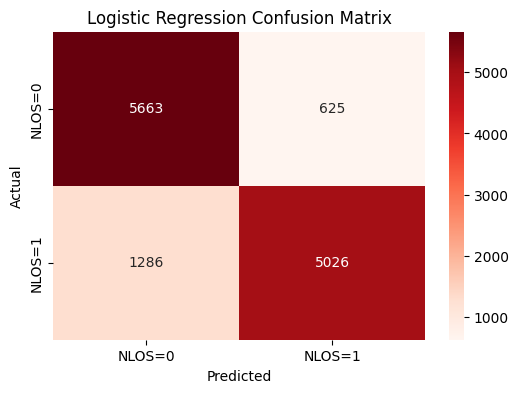


Classification Report:
              precision    recall  f1-score   support

         0.0       0.81      0.90      0.86      6288
         1.0       0.89      0.80      0.84      6312

    accuracy                           0.85     12600
   macro avg       0.85      0.85      0.85     12600
weighted avg       0.85      0.85      0.85     12600



In [30]:
from sklearn.metrics import classification_report, confusion_matrix

logreg_auc_score = roc_auc_score(y_test, y_pred_logreg)

print("Logistic Regression AUC-ROC score: {:.2f}%".format(logreg_auc_score * 100))

# Compute and display the confusion matrix
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
print("Confusion Matrix:")
print(cm_logreg)

plt.figure(figsize=(6,4))
sns.heatmap(cm_logreg, annot=True, fmt="d", cmap="Reds",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

# Print a classification report which includes precision, recall, f1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logreg))
log_reg_class_report = classification_report(y_test, y_pred_logreg, output_dict=True)
logreg_0_f1 = log_reg_class_report['0.0']['f1-score']
logreg_1_f1 = log_reg_class_report['1.0']['f1-score']

Train MLP neural network model

In [31]:
from sklearn.neural_network import MLPClassifier

# Create and train the neural network classifier
# Here we use one hidden layer with 100 neurons. You can adjust hidden_layer_sizes, max_iter, etc.
mlp = MLPClassifier(hidden_layer_sizes=(100,), max_iter=300, random_state=111)
mlp.fit(X_train, y_train)

# Predict on the test set
y_pred_mlp = mlp.predict(X_test)

Evaluate MLP neural network model using AUC score and confusion matrix

MLP AUC-ROC score: 0.8262
Confusion Matrix:
[[4900 1388]
 [ 801 5511]]


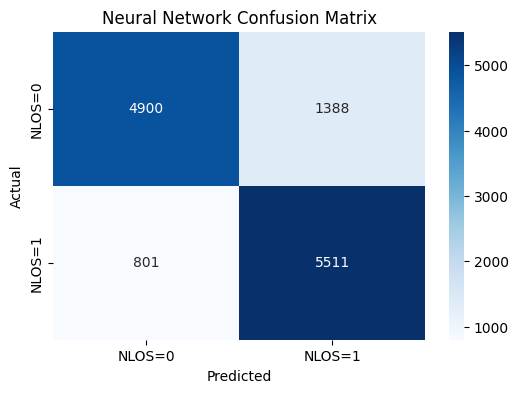


Classification Report:
              precision    recall  f1-score   support

         0.0       0.86      0.78      0.82      6288
         1.0       0.80      0.87      0.83      6312

    accuracy                           0.83     12600
   macro avg       0.83      0.83      0.83     12600
weighted avg       0.83      0.83      0.83     12600



In [32]:
# Evaluate the performance
MLP_auc_score = roc_auc_score(y_test, y_pred_mlp)
print("MLP AUC-ROC score: {:.4f}".format(MLP_auc_score))

# Compute the confusion matrix
cm_nn = confusion_matrix(y_test, y_pred_mlp)
print("Confusion Matrix:")
print(cm_nn)

# Visualize the confusion matrix with custom labels
plt.figure(figsize=(6,4))
sns.heatmap(cm_nn, annot=True, fmt="d", cmap="Blues",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Neural Network Confusion Matrix")
plt.show()

# Print a classification report which includes precision, recall, f1-score
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp))
MLP_class_report = classification_report(y_test, y_pred_mlp, output_dict=True)
MLP_0_f1 = MLP_class_report['0.0']['f1-score']
MLP_1_f1 = MLP_class_report['1.0']['f1-score']

Train KNN model to find the best K value

k = 1 => Training Accuracy: 1.0000, Test Accuracy: 0.7707
k = 5 => Training Accuracy: 0.8619, Test Accuracy: 0.7972
k = 6 => Training Accuracy: 0.8478, Test Accuracy: 0.7997
k = 7 => Training Accuracy: 0.8506, Test Accuracy: 0.7964
k = 8 => Training Accuracy: 0.8402, Test Accuracy: 0.7987
k = 10 => Training Accuracy: 0.8358, Test Accuracy: 0.7980
k = 15 => Training Accuracy: 0.8292, Test Accuracy: 0.7986
k = 20 => Training Accuracy: 0.8196, Test Accuracy: 0.7954
k = 25 => Training Accuracy: 0.8158, Test Accuracy: 0.7958
k = 30 => Training Accuracy: 0.8124, Test Accuracy: 0.7923


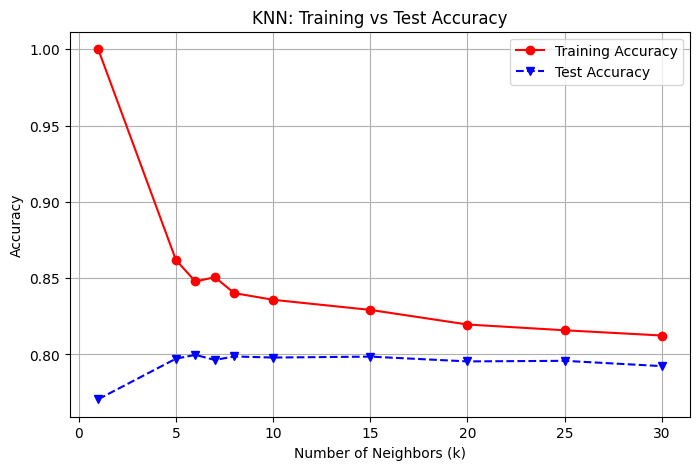

In [33]:
from sklearn.neighbors import KNeighborsClassifier

numNeighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30]
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    y_predTrain = clf1.predict(X_train)
    y_predTest = clf1.predict(X_test)
    trainAcc.append(roc_auc_score(y_train, y_predTrain))
    testAcc.append(roc_auc_score(y_test, y_predTest))
    print(f"k = {k} => Training Accuracy: {roc_auc_score(y_train, y_predTrain):.4f}, Test Accuracy: {roc_auc_score(y_test, y_predTest):.4f}")

plt.figure(figsize=(8,5))
plt.plot(numNeighbors, trainAcc, 'ro-', label='Training Accuracy')
plt.plot(numNeighbors, testAcc, 'bv--', label='Test Accuracy')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Accuracy')
plt.title('KNN: Training vs Test Accuracy')
plt.legend()
plt.grid(True)
plt.show()

Train another KNN model with best K value

In [34]:
# 1. Create and train the final KNN model on the training set
final_knn = KNeighborsClassifier(n_neighbors=7, metric='minkowski', p=2)
final_knn.fit(X_train, y_train)

# 2. Predict on the test set
y_pred_knn = final_knn.predict(X_test)

Evaluate KNN model using AUC score and confusion matrix

KNN AUC-ROC score: 0.7963841440996914
Confusion Matrix:
[[5385  903]
 [1664 4648]]


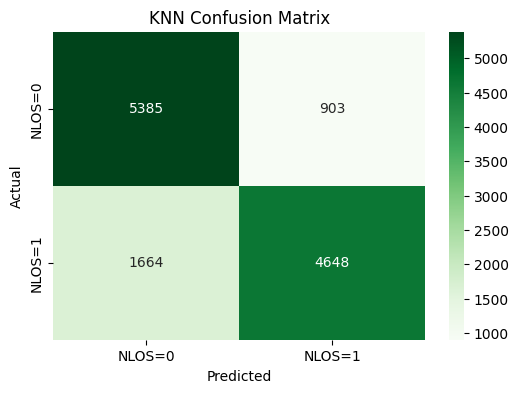


Classification Report:
              precision    recall  f1-score   support

         0.0       0.76      0.86      0.81      6288
         1.0       0.84      0.74      0.78      6312

    accuracy                           0.80     12600
   macro avg       0.80      0.80      0.80     12600
weighted avg       0.80      0.80      0.80     12600



In [41]:
# 3. Evaluate Performance
KNN_auc_score = roc_auc_score(y_test, y_pred_knn)
print("KNN AUC-ROC score:", KNN_auc_score)

cm = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:")
print(cm)

# 4. Visualize the confusion matrix with custom labels
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["NLOS=0", "NLOS=1"],
            yticklabels=["NLOS=0", "NLOS=1"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))
KNN_class_report = classification_report(y_test, y_pred_knn, output_dict=True)
KNN_0_f1 = KNN_class_report['0.0']['f1-score']
KNN_1_f1 = KNN_class_report['1.0']['f1-score']

Compare metrics for all 3 models

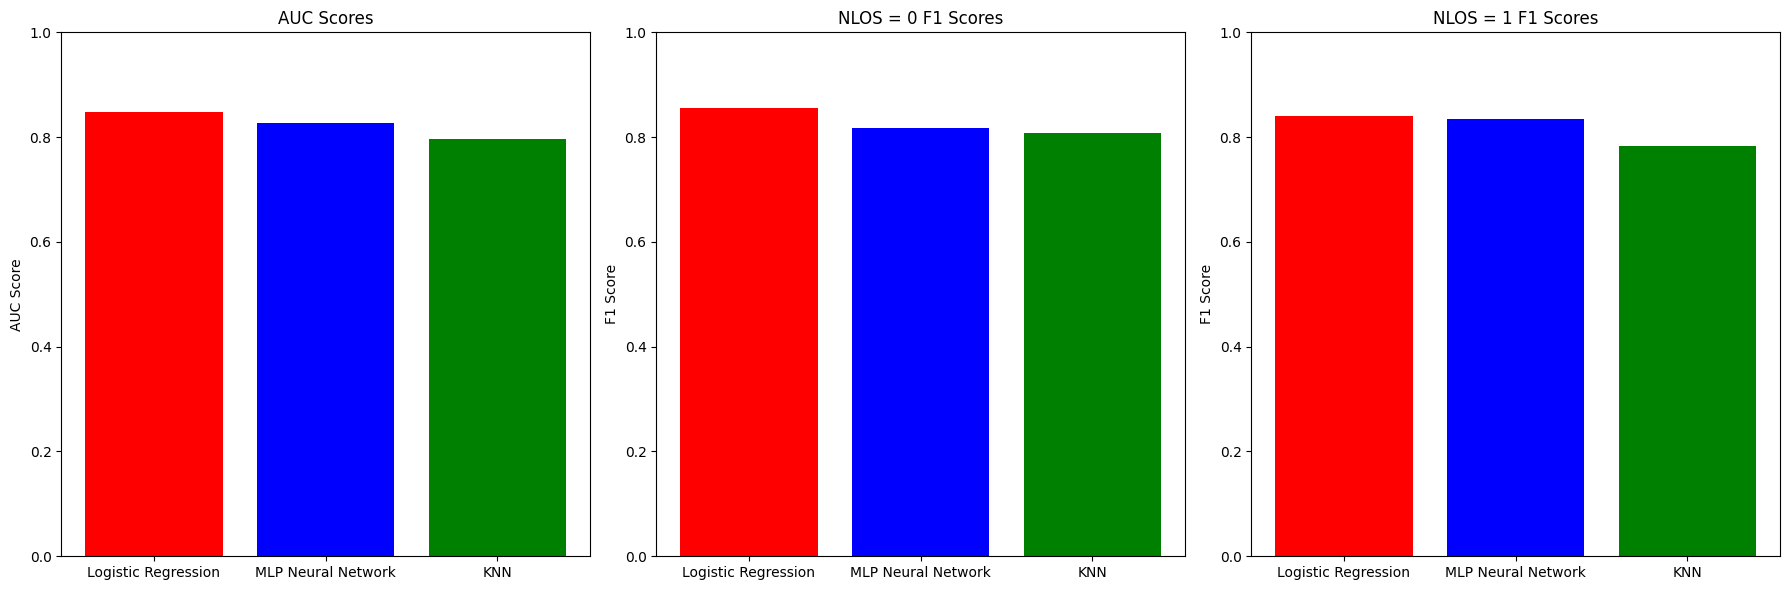

In [40]:
# Prepare data for plotting
models = ['Logistic Regression', 'MLP Neural Network', 'KNN']
auc_scores = [logreg_auc_score, MLP_auc_score, KNN_auc_score]
NLOS_0_f1_scores = [logreg_0_f1, MLP_0_f1, KNN_0_f1]
NLOS_1_f1_scores = [logreg_1_f1, MLP_1_f1, KNN_1_f1]

# Create subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

# Plot AUC scores
ax1.bar(models, auc_scores, color=['red', 'blue', 'green'])
ax1.set_title('AUC Scores')
ax1.set_ylabel('AUC Score')
ax1.set_ylim(0, 1)

# Plot NLOS = 0 F1 scores
ax2.bar(models, NLOS_0_f1_scores, color=['red', 'blue', 'green'])
ax2.set_title('NLOS = 0 F1 Scores')
ax2.set_ylabel('F1 Score')
ax2.set_ylim(0, 1)

# Plot NLOS = 1 F1 scores
ax3.bar(models, NLOS_1_f1_scores, color=['red', 'blue', 'green'])
ax3.set_title('NLOS = 1 F1 Scores')
ax3.set_ylabel('F1 Score')
ax3.set_ylim(0, 1)

# Display the plots
plt.tight_layout()
plt.show()

The metrics show that the Logistic Regression model performed the best at classifying NLOS given the features in the preprocessed dataset for classifying.